In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from importlib import reload
import vis; reload(vis)

df = pd.read_csv('./v2_summary.csv')

ovars = ['objective', 'cost']
dvars = ['size', 'cable']

self = vis.Visualizer(
    data=df[ovars + dvars],
    data_ovars=ovars, data_dvars=dvars
)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X = df.set_index(['location', 'technology'])\
    .sort_index()

y = X.objective

X.drop(columns=['objective'], inplace=True)

X

capacity  duration     cost  power       size  \
location   technology                                                  
COTTONWOOD LAB           1810.0         2   896.89   1000  45.068999   
           LAB           1810.0         2   957.58    100  45.068999   
           LAB           1810.0         4  1622.89   1000  45.068999   
           LAB           1810.0         4  1723.50    100  41.770469   
           LAB           1810.0         6  2348.03   1000  21.343832   
...                         ...       ...      ...    ...        ...   
WCASCADE   VRF           1500.0         4  2599.45    100   5.703987   
           VRF           1500.0         6  3248.67   1000   0.000021   
           VRF           1500.0         6  3420.59    100   0.000010   
           VRF           1500.0         8  3652.63   1000   0.000008   
           VRF           1500.0         8  3846.21    100   0.000005   

                             cable  
location   technology               
COTTONWOOD LAB         1638.758919  
           LAB         1638.758919  
           LAB         1638.758918  
           LAB         1637.247092  
           LAB         1627.884883  
...                            ...  
WCASCADE   VRF         1343.583079  
           VRF         1340.968762  
           VRF         1340.968756  
           VRF         1340.968755  
           VRF         1340.968754  

[160 rows x 6 columns]

COTTONWOOD LAB
COTTONWOOD LFP
COTTONWOOD NMC
COTTONWOOD VRF
JOHNDAY LAB
JOHNDAY LFP
JOHNDAY NMC
JOHNDAY VRF
MOSSLAND LAB
MOSSLAND LFP
MOSSLAND NMC
MOSSLAND VRF
TESLA LAB
TESLA LFP
TESLA NMC
TESLA VRF
WCASCADE LAB
WCASCADE LFP
WCASCADE NMC
WCASCADE VRF


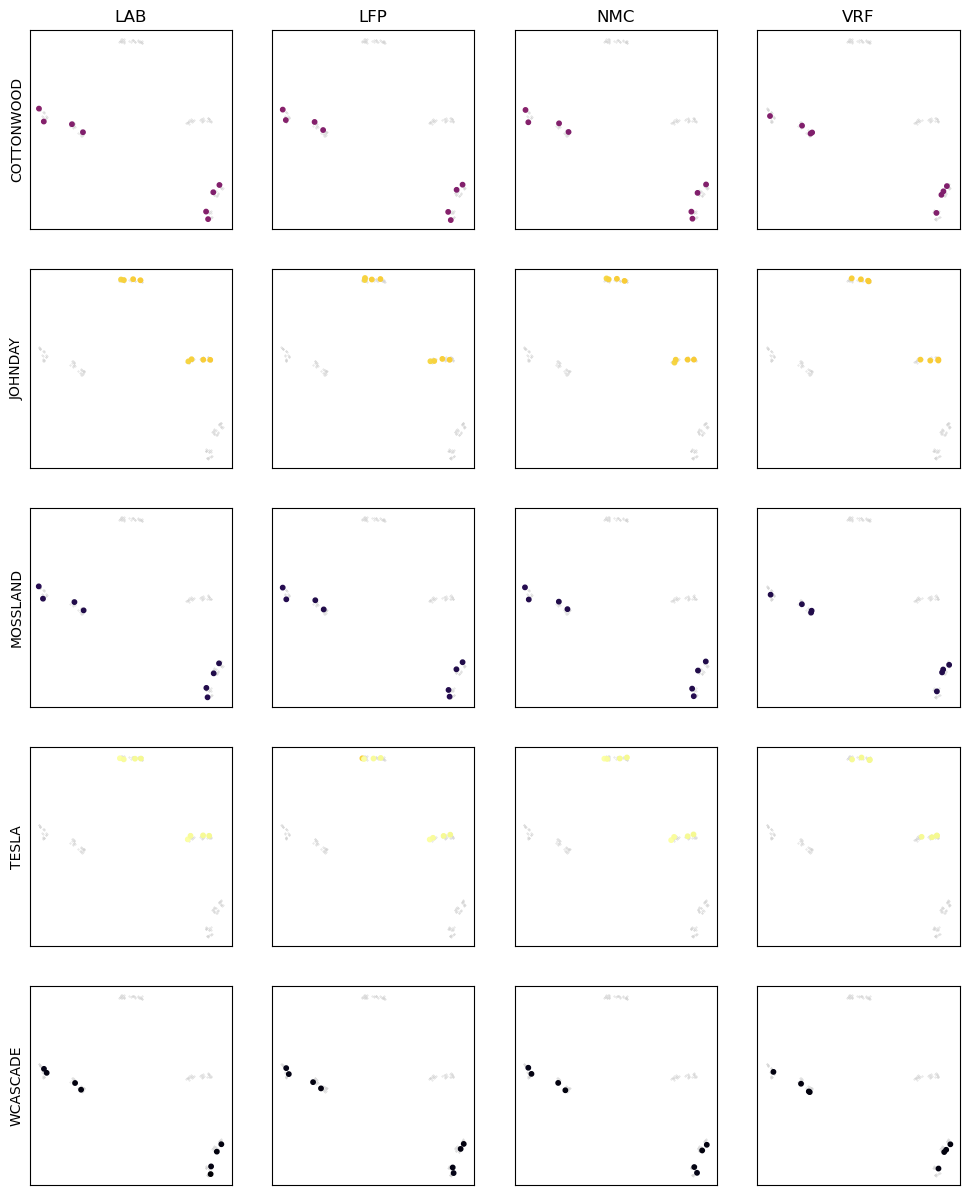

In [6]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def get_index(level):
    return {
        v: i
        for i, v in enumerate(X.index.get_level_values(level).unique())
    }

rows = get_index(0)
cols = get_index(1)

pipe = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP())
])

xy = pd.DataFrame(
    pipe.fit_transform(X),
    index=X.index
)

s = 3
plt.figure(figsize=(s*len(cols), s*len(rows)))

norm = plt.Normalize(y.min(), y.max())
cmap = plt.cm.inferno

for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        ax = plt.subplot(len(rows), len(cols), i*len(cols) + j + 1)
        if (r, c) in xy.index:
            print(r, c)
            ax.scatter(*xy.values.T, s=.1, c='lightgray')
            ax.scatter(
                *xy.loc[r, c].values.T,
                s=10,
                c=cmap(norm(y.loc[r, c]))
            )

        plt.xticks([], [])
        plt.yticks([], [])
        
        if j == 0:
            plt.ylabel(r)
            
        if i == 0:
            plt.title(c)


/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden

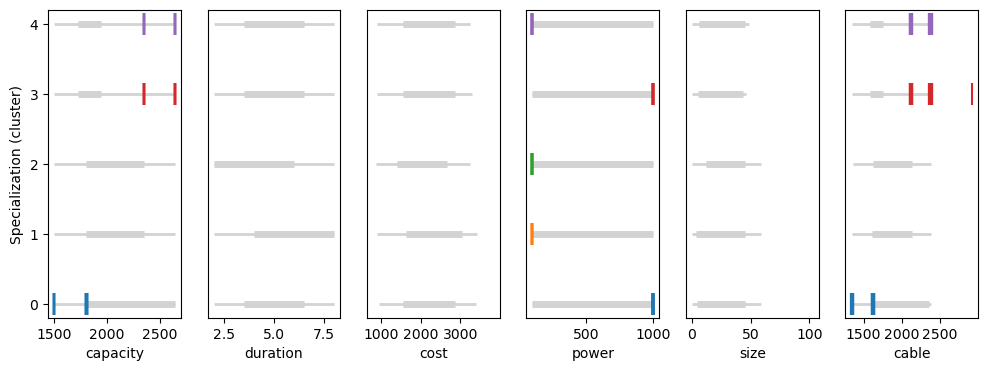

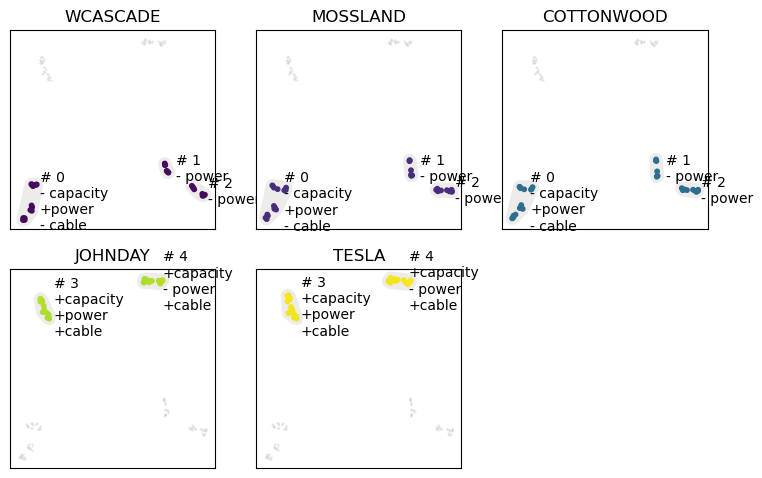

<Figure size 1200x1500 with 0 Axes>

<Figure size 600x300 with 0 Axes>

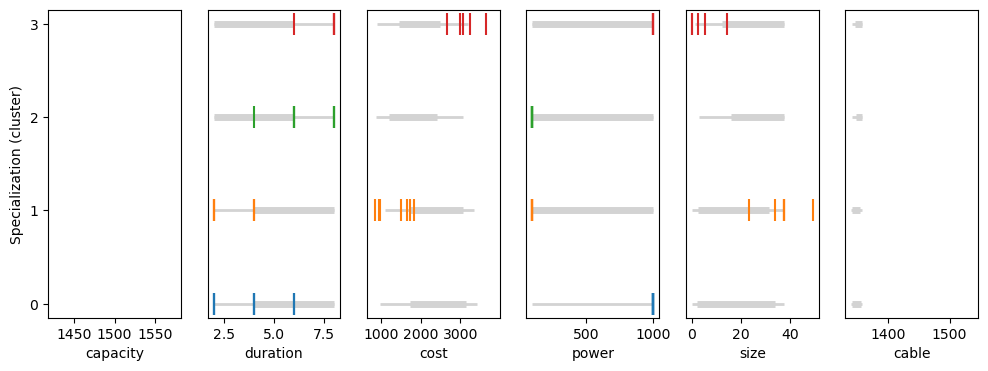

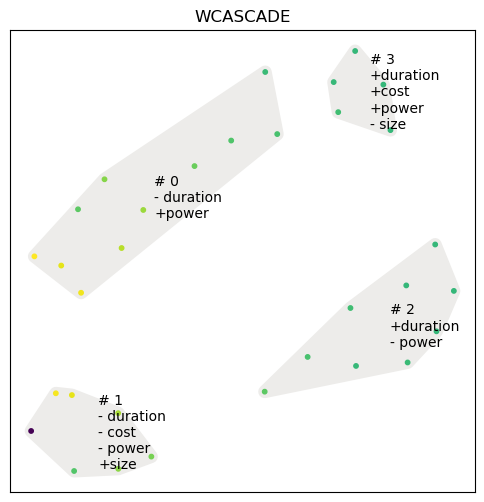

<Figure size 600x300 with 0 Axes>

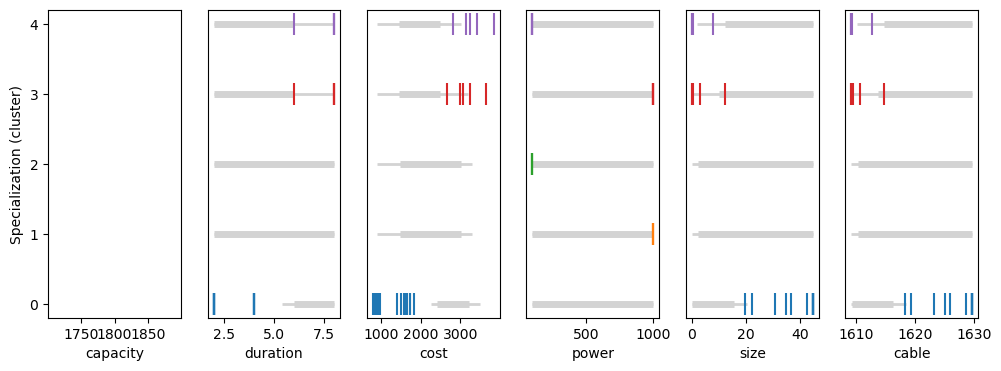

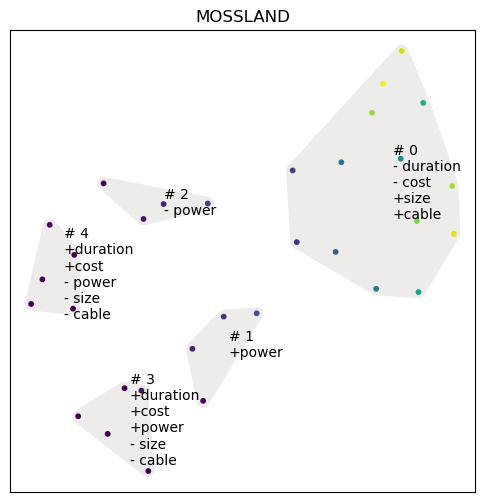

<Figure size 600x300 with 0 Axes>

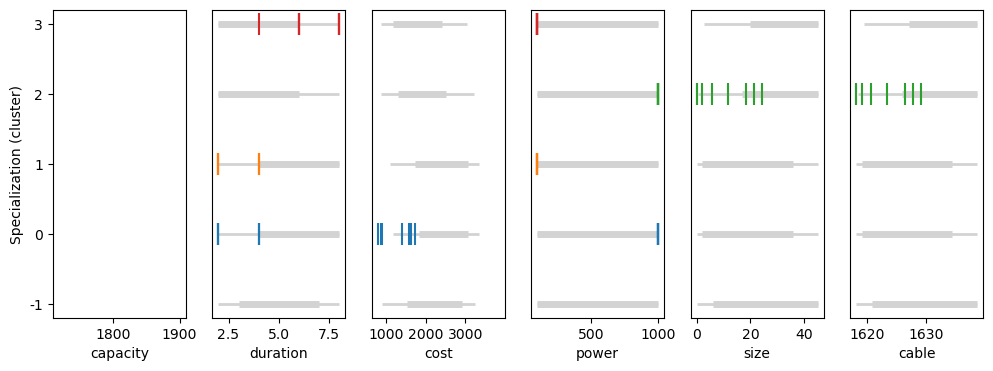

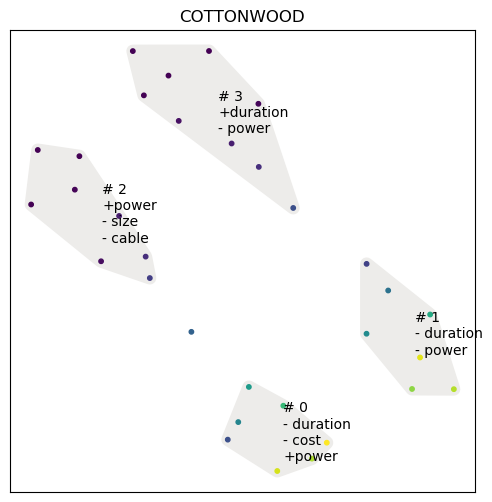

<Figure size 600x300 with 0 Axes>

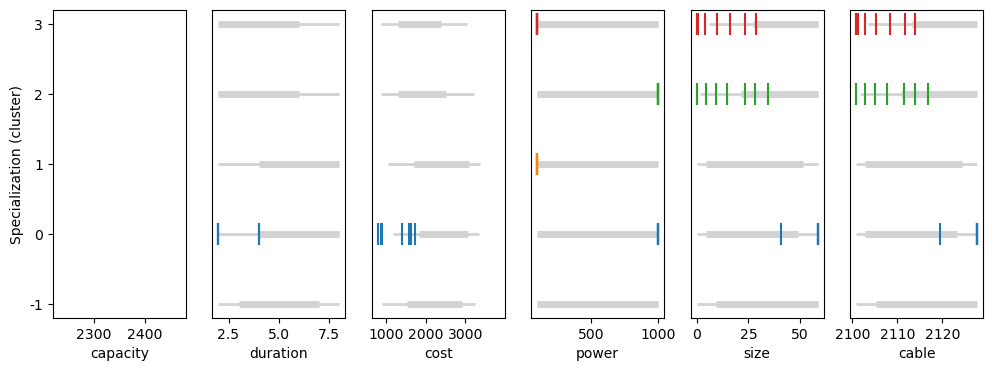

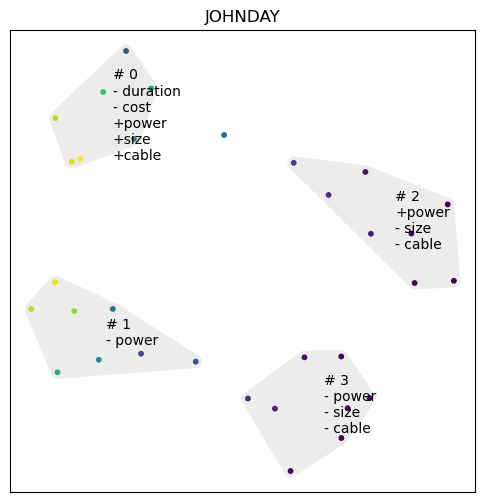

<Figure size 600x300 with 0 Axes>

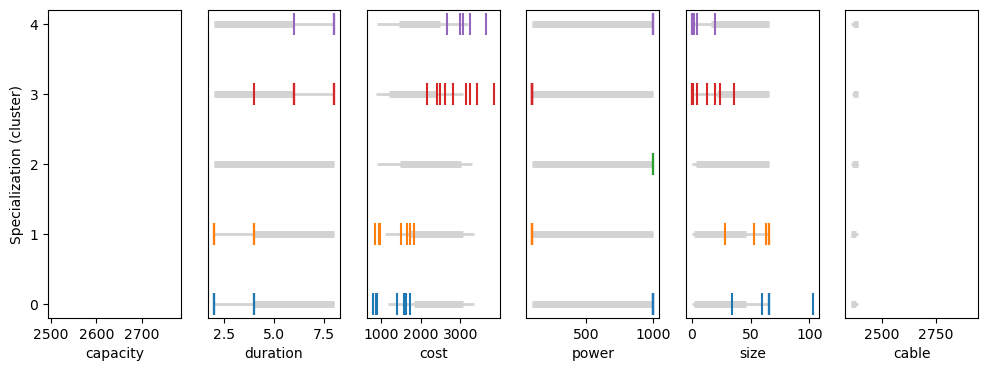

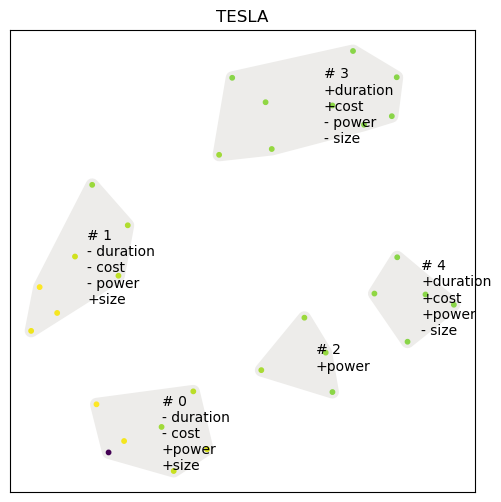

In [8]:
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN

reload(vis)

def draw_scatter_with_labels(xy, y_cluster, hue, coef, threshold=1.0, cmap=plt.cm.viridis, vmin=None, vmax=None, ax=None):
    ax = ax or plt.gca()

    norm = plt.Normalize(vmin, vmax)
    vis.get_cluster_hulls(xy, y_cluster, marker_color=cmap(norm(hue)), marker_size=10, with_labels=False)

    if coef is not None:
        def get_label(ser):
            names = [
                f'{"+" if np.sign(v) > 0 else "- "}{k}'
                for k, v in ser.items()
                if abs(v) > threshold
            ]
            return '\n'.join(names)
            
        labels = coef.apply(get_label, axis=1)
        centroids = xy.groupby(y_cluster).mean()

        for ci in set(y_cluster):
            if ci != -1:
                ax.annotate(
                    f'# {ci}\n{labels.loc[ci]}', centroids.loc[ci],
                    va='center',
                    xytext=(7, 0),
                    textcoords='offset points'
                )
            
def draw_faceted_umap_global(pipe, X, y, s=3, ncols=3):
    rows = y.groupby(level=0).mean().sort_values()
    nrows = len(rows)

    y_cluster = pd.Series(pipe.fit_predict(X), index=X.index)
    xy = pd.DataFrame(pipe['proj'].embedding_, index=X.index)
    
    threshold = 1.0
    coef = vis.explain_groups(
        X,
        y_cluster,
        colors=plt.cm.tab10(y_cluster), threshold=threshold, xlim=None
    )

    kwargs = dict(
        vmin=y.min(),
        vmax=y.max(),
        coef=coef
    )

    plt.figure(figsize=(s*ncols, s*nrows))
    for i, (r, v) in enumerate(rows.items()):
        ax = plt.subplot(nrows, ncols, i + 1)
        plt.title(r)
        
        ax.scatter(*xy.values.T, s=.1, c='lightgray')
        draw_scatter_with_labels(
            xy.loc[r], y_cluster.loc[r],
            hue=y.loc[r],
            ax=ax,
            **kwargs
        )

        plt.xticks([], [])
        plt.yticks([], [])

def draw_faceted_umap_local(pipe, X, y, s=3, ncols=3, threshold=.5):
    rows = y.groupby(level=0).mean().sort_values()
    nrows = len(rows)
    ncols = 2

    plt.figure(figsize=(2*s*ncols, s*nrows))
    for i, (r, v) in enumerate(rows.items()):
        Xr = X.loc[r]        
        y_cluster_r = pd.Series(pipe.fit_predict(Xr), index=Xr.index)
        xy_r = pd.DataFrame(pipe['proj'].embedding_, index=Xr.index)
        y_r = y.loc[r]
        
        plt.figure(figsize=(6, 3))
        coef = vis.explain_groups(
            Xr,
            y_cluster_r,
            colors=plt.cm.tab10(y_cluster_r),
            threshold=threshold,
            xlim=None
        ) if y_cluster_r.nunique() > 1 else None

        plt.figure(figsize=(6, 6))
        draw_scatter_with_labels(
            xy_r,
            y_cluster_r,
            hue=y_r,
            coef=coef,
            threshold=threshold
        )
        plt.title(r)
        plt.xticks([], [])
        plt.yticks([], [])



args = (
    X.reset_index('technology', drop=True),
    y.reset_index('technology', drop=True)
)

pipe1 = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=2.0))
])
draw_faceted_umap_global(pipe1, *args)

pipe2 = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=.65, min_samples=2))
])
draw_faceted_umap_local(pipe2, *args)

# add colormap

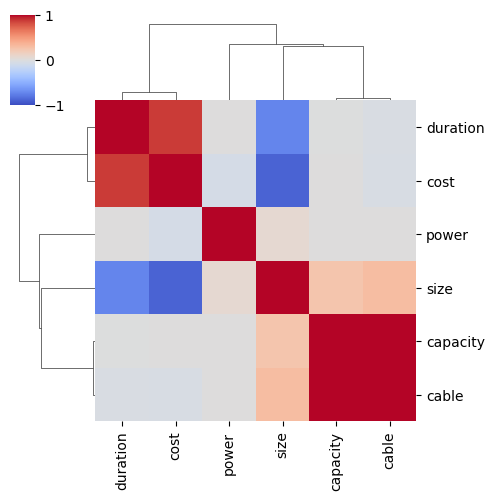

In [10]:
import seaborn as sns

C = X.corr()
sns.clustermap(C, cmap='coolwarm', vmin=-1, vmax=1, figsize=(5,5))

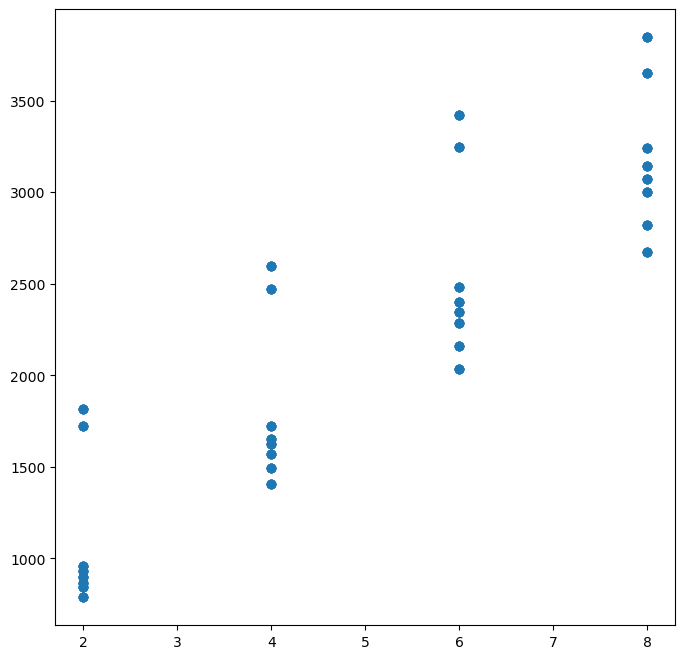

In [11]:
plt.scatter(X.duration, X.cost)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

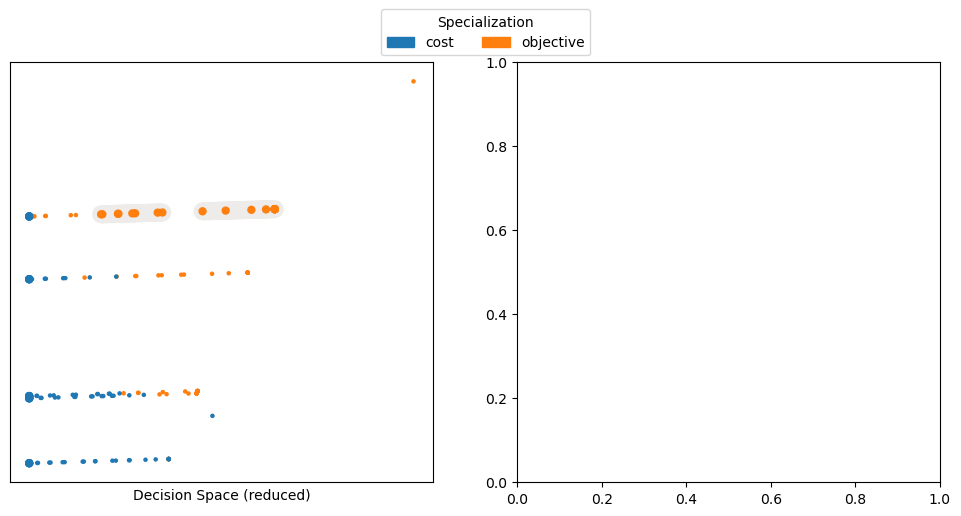

In [12]:
reload(vis)

self.show_specialization_clustering(
    left_xy=self.df[self.dvars],
    
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from umap import UMAP

pipe = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=.5))
])

X_with_objective = X.assign(objective=y)
cluster = pipe.fit_predict(X_with_objective)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


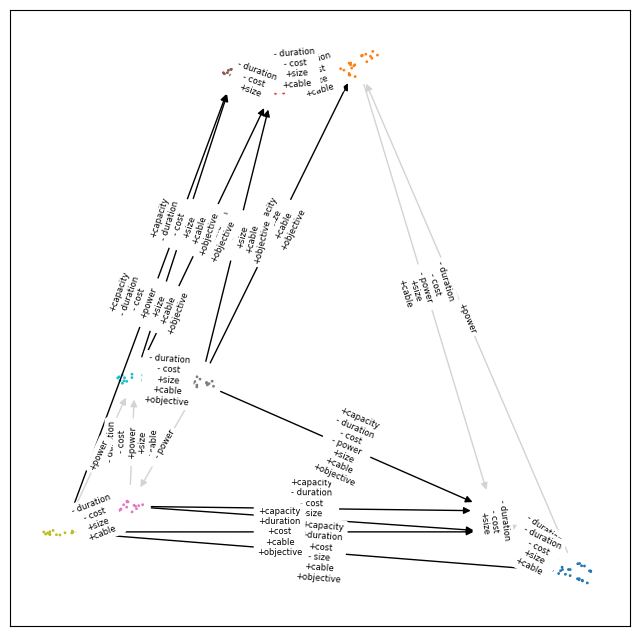

In [14]:
import numpy as np
from scipy.spatial import Delaunay
import networkx as nx
from scipy.stats import mannwhitneyu

def test_all(X, Y):
    result = pd.DataFrame([
        mannwhitneyu(X[c], Y[c])
        for c in X
    ], index=X.columns)

    df = pd.DataFrame([X.median(), Y.median()])
    result['magnitude'] = df.max() / df.min()

    result['direction'] = np.sign(result.statistic/(len(X)*len(Y)) - .5)
    
    return result
    
def get_groups(result, alpha=.01):
    mask = result.pvalue < alpha
    return (
        result.index[np.logical_and(mask, result.direction > 0)],
        result.index[np.logical_and(mask, result.direction < 0)]
    )

def get_group_label(result, u, v):
    def as_str(li):
        return f'({", ".join(li)})'
        
    gu, gv = get_groups(result)
    return f'{u}:{as_str(gu)} {v}:{as_str(gv)}'

def get_triangulation(points):
    G = nx.Graph()

    for i, xy in enumerate(points):
        G.add_node(i, pos=xy)
    
    tri = Delaunay(points)
    for i, j, k in tri.simplices:
        G.add_edge(i, j)
        G.add_edge(j, k)
        G.add_edge(k, i)

    return G

def get_tradeoff_lattice(X, xy, cluster):
    centroids = pd.DataFrame(xy).groupby(cluster).mean().values

    G = get_triangulation(centroids)
    
    for u, v, d in G.edges(data=True):
        d['test'] = test_all(X[cluster == u], X[cluster == v])

    return G


def draw_tradeoff_lattice(G, xy, cluster, use_centroid_pos=True, with_labels=True, by=None, alpha=.05, edge_labels_kwargs=dict()):
    if by is not None:
        G = reorient_lattice(
            G, by='objective'
        )

    if use_centroid_pos:
        plt.scatter(*xy.T, c=cluster, cmap=plt.cm.tab10, vmin=0, vmax=9, s=1)
        pos = {
            v: G.nodes[v]['pos']
            for v in G
        }
    else:
        pos = nx.kamada_kawai_layout(G)
    
    
    # nx.draw_networkx_nodes(G, pos, edgecolors='lightgray', node_color='none')
    nx.draw_networkx_edges(
        G, pos,
        node_size=1000,
        edge_color=[
            'black' if by is None or d['test'].loc[by, 'pvalue'] < alpha else 'lightgray'
            for u, v, d in G.edges(data=True)
        ]
    )

    def create_label(d):
        test = d['test']
        return '\n'.join([
            f'{"+" if ser.direction > 0 else "- "}{k}'
            for k, ser in test[test.pvalue < alpha].iterrows()
        ])

    if with_labels:
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels={
                (u, v): create_label(d)
                for u, v, d in G.edges(data=True)
            },
            **edge_labels_kwargs
        )

    return G

def reorient_lattice(G, by, alpha=.01):
    D = nx.DiGraph()

    # copy nodes and data from G into D
    for v, d in G.nodes(data=True):
        D.add_node(v, **d)

    # copy edges, but flip baed on direction of by variable
    for u, v, d in G.edges(data=True):
        test = d['test'].copy()

        if test.loc[by, 'direction'] < 0:
            v, u = u, v
            test['direction'] *= -1
            
        D.add_edge(u, v, test=test)

    return D

xy = pipe['proj'].embedding_
G = get_tradeoff_lattice(X_with_objective, xy, cluster)

plt.figure()
draw_tradeoff_lattice(
    G, xy, cluster,
    by='objective',
    with_labels=True,
    use_centroid_pos=True,
    edge_labels_kwargs=dict(
        font_size=6
    )
)

In [15]:
X

capacity  duration     cost  power       size  \
location   technology                                                  
COTTONWOOD LAB           1810.0         2   896.89   1000  45.068999   
           LAB           1810.0         2   957.58    100  45.068999   
           LAB           1810.0         4  1622.89   1000  45.068999   
           LAB           1810.0         4  1723.50    100  41.770469   
           LAB           1810.0         6  2348.03   1000  21.343832   
...                         ...       ...      ...    ...        ...   
WCASCADE   VRF           1500.0         4  2599.45    100   5.703987   
           VRF           1500.0         6  3248.67   1000   0.000021   
           VRF           1500.0         6  3420.59    100   0.000010   
           VRF           1500.0         8  3652.63   1000   0.000008   
           VRF           1500.0         8  3846.21    100   0.000005   

                             cable  
location   technology               
COTTONWOOD LAB         1638.758919  
           LAB         1638.758919  
           LAB         1638.758918  
           LAB         1637.247092  
           LAB         1627.884883  
...                            ...  
WCASCADE   VRF         1343.583079  
           VRF         1340.968762  
           VRF         1340.968756  
           VRF         1340.968755  
           VRF         1340.968754  

[160 rows x 6 columns]

In [16]:
import seaborn as sns

import warnings; warnings.simplefilter('ignore')


s = 5
nrows = ncols = len(G)

G = D.to_undirected()
order = nx.spectral_ordering(G)
X_scaled = (X - X.mean())/X.std()

plt.figure(figsize=(s*ncols, s*nrows))

for i, u in enumerate(order):
    for j, v in enumerate(order):
        
        if i > j and (u, v) in G.edges:
            result = G.get_edge_data(u, v)['test']
            
            ax = plt.subplot(nrows, ncols, i*ncols + j + 1)
            ax.set_title(get_group_label(result, u, v))
            
            mask = np.logical_or(cluster == u, cluster == v)
            data = X_scaled[mask]\
                .assign(cluster=cluster[mask])\
                .melt(id_vars='cluster')
            
            sns.stripplot(data, x='value', y='variable', hue='cluster', palette=[plt.cm.tab10(i) for i in (u, v)], ax=ax)
            ax.set_xlabel('Z-score')

NameError: name 'D' is not defined

In [ ]:
!open .